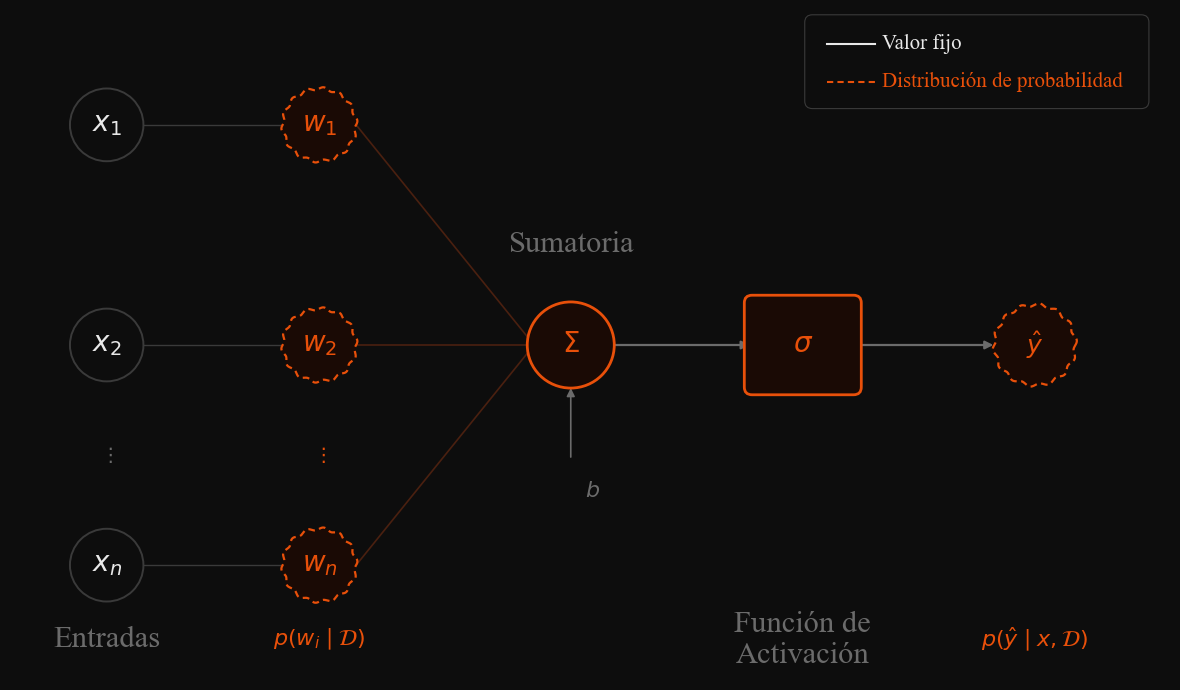

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import numpy as np

# ── Paleta CUNEF ──────────────────────────────────────────
CUNEF_ORANGE = "#E8500A"
CUNEF_AMBER  = "#F4A261"
CUNEF_DARK   = "#0D0D0D"
CUNEF_PANEL  = "#141414"
CUNEF_GRAY   = "#6B6B6B"
CUNEF_LGRAY  = "#3A3A3A"
WHITE        = "#E8E8E8"

mpl.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "figure.facecolor": CUNEF_DARK,
    "text.color":       WHITE,
})

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor(CUNEF_DARK)
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

# ── Helpers (iguales que tu código) ───────────────────────
def circulo(x, y, r=0.38, fc=CUNEF_DARK, ec=CUNEF_ORANGE, lw=1.8, zorder=4):
    c = plt.Circle((x, y), r, fc=fc, ec=ec, linewidth=lw, zorder=zorder)
    ax.add_patch(c)

def rect_redondeado(x, y, w, h, fc=CUNEF_DARK, ec=CUNEF_ORANGE, lw=1.8, zorder=4):
    r = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.08",
        fc=fc, ec=ec, linewidth=lw, zorder=zorder
    )
    ax.add_patch(r)

def flecha(x1, y1, x2, y2, color=CUNEF_LGRAY, lw=1.2, style="-|>"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color,
                                lw=lw, mutation_scale=12), zorder=3)

def linea(x1, y1, x2, y2, color=CUNEF_LGRAY, lw=1.0, ls="-"):
    ax.plot([x1, x2], [y1, y2], color=color, lw=lw, ls=ls, zorder=2)

# ── NUEVO: círculo ondulado (distribución) ────────────────
def circulo_bayesiano(x, y, r=0.38, color=CUNEF_ORANGE, lw=1.8, zorder=4,
                      fc="#1A0A05", n_ondas=14, amp=0.04):
    """Círculo con borde ondulado para representar distribución de probabilidad."""
    theta = np.linspace(0, 2 * np.pi, 500)
    ondas = 1 + amp * np.sin(n_ondas * theta)
    xp = x + r * ondas * np.cos(theta)
    yp = y + r * ondas * np.sin(theta)
    # Fondo
    ax.fill(xp, yp, color=fc, zorder=zorder)
    # Borde ondulado
    ax.plot(xp, yp, color=color, lw=lw, zorder=zorder + 1,
            linestyle="--", dashes=(3, 2))

# ── Posiciones (idénticas) ────────────────────────────────
xs_x  = [(1.0, 5.8), (1.0, 3.5), (1.0, 1.2)]
xs_w  = [(3.2, 5.8), (3.2, 3.5), (3.2, 1.2)]
sum_x, sum_y = 5.8, 3.5
act_x, act_y = 8.2, 3.5
sal_x, sal_y = 10.6, 3.5

# ── Conexiones ────────────────────────────────────────────
for (xx, xy), (wx, wy) in zip(xs_x, xs_w):
    linea(xx + 0.38, xy, wx - 0.38, wy, color=CUNEF_LGRAY, lw=1.0)

for wx, wy in xs_w:
    linea(wx + 0.38, wy, sum_x - 0.38, sum_y, color="#4A2010", lw=1.2)

flecha(sum_x + 0.38, sum_y, act_x - 0.52, act_y, color=CUNEF_GRAY, lw=1.6)
flecha(act_x + 0.52, act_y, sal_x - 0.40, sal_y, color=CUNEF_GRAY, lw=1.6)
flecha(sum_x, 2.3, sum_x, sum_y - 0.42, color=CUNEF_GRAY, lw=1.2)

# ── Entradas: círculos normales (valores fijos) ───────────
labels_x = [r"$x_1$", r"$x_2$", r"$x_n$"]
for (xx, xy), lbl in zip(xs_x, labels_x):
    circulo(xx, xy, ec=CUNEF_LGRAY, fc=CUNEF_DARK, lw=1.4)
    ax.text(xx, xy, lbl, ha="center", va="center",
            fontsize=20, color=WHITE, zorder=5)

ax.text(xs_x[0][0], (xs_x[1][1] + xs_x[2][1]) / 2,
        r"$\vdots$", ha="center", va="center",
        fontsize=14, color=CUNEF_GRAY, zorder=5)

# ── Pesos: círculos BAYESIANOS (distribuciones) ───────────
labels_w = [r"$w_1$", r"$w_2$", r"$w_n$"]
for (wx, wy), lbl in zip(xs_w, labels_w):
    circulo_bayesiano(wx, wy, color=CUNEF_ORANGE, lw=1.6)
    ax.text(wx, wy, lbl, ha="center", va="center",
            fontsize=20, color=CUNEF_ORANGE, zorder=6)

ax.text(xs_w[0][0], (xs_w[1][1] + xs_w[2][1]) / 2,
        r"$\vdots$", ha="center", va="center",
        fontsize=14, color=CUNEF_ORANGE, zorder=6)

# Label bajo pesos: p(w_i | D)
ax.text(xs_w[0][0], 0.42, r"$p(w_i \mid \mathcal{D})$",
        ha="center", va="center", fontsize=16,
        color=CUNEF_ORANGE, zorder=5)

# ── Sumatoria ─────────────────────────────────────────────
circulo(sum_x, sum_y, r=0.45, ec=CUNEF_ORANGE, fc="#1A0A05", lw=2.0)
ax.text(sum_x, sum_y, r"$\Sigma$", ha="center", va="center",
        fontsize=20, color=CUNEF_ORANGE, zorder=5)

# ── Activación ────────────────────────────────────────────
rect_redondeado(act_x, act_y, w=1.05, h=0.88,
                fc="#1A0A05", ec=CUNEF_ORANGE, lw=2.0)
ax.text(act_x, act_y, r"$\sigma$", ha="center", va="center",
        fontsize=20, color=CUNEF_ORANGE, zorder=5)

# ── Salida: BAYESIANA (distribución) ─────────────────────
circulo_bayesiano(sal_x, sal_y, r=0.42, color=CUNEF_ORANGE, lw=1.6)
ax.text(sal_x, sal_y, r"$\hat{y}$", ha="center", va="center",
        fontsize=18, color=CUNEF_ORANGE, zorder=6)

# Label bajo salida: p(ŷ | x, D)
ax.text(sal_x, 0.42, r"$p(\hat{y} \mid x, \mathcal{D})$",
        ha="center", va="center", fontsize=16,
        color=CUNEF_ORANGE, zorder=5)

# ── Bias ──────────────────────────────────────────────────
ax.text(sum_x + 0.15, 2.08, r"$b$", ha="left", va="top",
        fontsize=16, color=CUNEF_GRAY, style="italic", zorder=5)

# ── Labels de sección ─────────────────────────────────────
ax.text(xs_x[0][0], 0.42, "Entradas", ha="center", va="center",
        fontsize=22, color=CUNEF_GRAY, zorder=5)
ax.text(sum_x, 4.55, "Sumatoria", ha="center", va="center",
        fontsize=22, color=CUNEF_GRAY, zorder=5)
ax.text(act_x, 0.42, "Función de\nActivación", ha="center", va="center",
        fontsize=22, color=CUNEF_GRAY, zorder=5, multialignment="center")

# ── Leyenda (esquina superior derecha) ───────────────────
# Marco
legend_box = mpatches.FancyBboxPatch(
    (8.3, 6.05), 3.4, 0.82,
    boxstyle="round,pad=0.08",
    fc=CUNEF_DARK, ec=CUNEF_LGRAY, lw=0.8, zorder=4
)
ax.add_patch(legend_box)

# Línea sólida = valor fijo
ax.plot([8.45, 8.95], [6.65, 6.65], color=WHITE, lw=1.5, zorder=5)
ax.text(9.02, 6.65, "Valor fijo", va="center",
        fontsize=15, color=WHITE, zorder=5)

# Línea discontinua = distribución
ax.plot([8.45, 8.95], [6.25, 6.25], color=CUNEF_ORANGE,
        lw=1.5, ls="--", dashes=(3, 2), zorder=5)
ax.text(9.02, 6.25, "Distribución de probabilidad", va="center",
        fontsize=15, color=CUNEF_ORANGE, zorder=5)

plt.tight_layout()
plt.savefig("images/neurona_bayesiana.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()